<a href="https://colab.research.google.com/github/nikolas-joyce/Event_Time/blob/main/VIX_SPY_Event_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VIX-SPY Event Study: Elevated VIX → SPY Bottom → Term Structure Dynamics
**Objective**: Analyze SPY behavior and VIX futures term structure during/after VIX spikes, plus implied correlation dynamics.

**Data Sources**:
- SPY/VIX spot: yfinance
- VIX futures: vix-utils
- Implied correlation: CBOE COR3M


In [2]:
!pip install yfinance vix-utils pandas numpy statsmodels matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.5/127.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.3/494.3 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 641.1/641.1 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existing installation: toolz 0.12.1
    Uninstalling toolz-0.12.1:
      Successfully uninstalled toolz-0.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.


In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
print(f"Starting data fetch: {datetime.now()}")
print("="*60)

# Date range
start, end = "1990-01-01", "2026-12-03"
print(f"Date range: {start} to {end}")
print()


Starting data fetch: 2025-12-03 23:09:17.788215
Date range: 1990-01-01 to 2026-12-03



In [23]:
# spy = yf.download("SPY", start=start, end=end, progress=True,auto_adjust=True)

# spy['Close']

In [24]:
print("1. Downloading SPY data...")
spy_data = yf.download("SPY", start=start, end=end, progress=False, auto_adjust=True)

# Assuming 'Close' price is in the 4th column (index 3) when columns are named ambiguously
# This is a common pattern for yfinance output with auto_adjust=True when explicit 'Close' name is missing.
spy = spy_data.iloc[:, 3]
spy.name = "SPY"
print(f"   SPY: {len(spy)} observations, {spy.index[0].date()} to {spy.index[-1].date()}")
print(f"   SPY range: ${spy.min():.2f} - ${spy.max():.2f}")

print("\n2. Downloading VIX data...")
vix_data = yf.download("^VIX", start=start, end=end, progress=False, auto_adjust=True)

# Assuming 'Close' price is in the 4th column (index 3) for VIX as well
vix = vix_data.iloc[:, 3]
vix.name = "VIX"
print(f"   VIX: {len(vix)} observations, {vix.index[0].date()} to {vix.index[-1].date()}")
print(f"   VIX range: {vix.min():.1f} - {vix.max():.1f}")

# Combine and clean
px = pd.concat([spy, vix], axis=1).dropna()
print(f"\n3. Combined dataset: {px.shape[0]} rows x {px.shape[1]} cols")
print(f"   Date range: {px.index[0].date()} to {px.index[-1].date()}")
print(f"   Missing data: {px.isnull().sum().sum()}")
print(f"   SPY/VIX correlation: {px['SPY'].corr(px['VIX']):.3f}")

# Save raw data for inspection
spy_data.to_csv('/content/spy_raw.csv')
vix_data.to_csv('/content/vix_raw.csv')
px.to_csv('/content/spot_data.csv')
print("   Saved: spot_data.csv, spy_raw.csv, vix_raw.csv")
print()

1. Downloading SPY data...
   SPY: 8269 observations, 1993-01-29 to 2025-12-03
   SPY range: $24.02 - $688.72

2. Downloading VIX data...
   VIX: 9048 observations, 1990-01-02 to 2025-12-03
   VIX range: 9.0 - 82.7

3. Combined dataset: 8269 rows x 2 cols
   Date range: 1993-01-29 to 2025-12-03
   Missing data: 0
   SPY/VIX correlation: -0.066
   Saved: spot_data.csv, spy_raw.csv, vix_raw.csv



<Axes: xlabel='Date'>

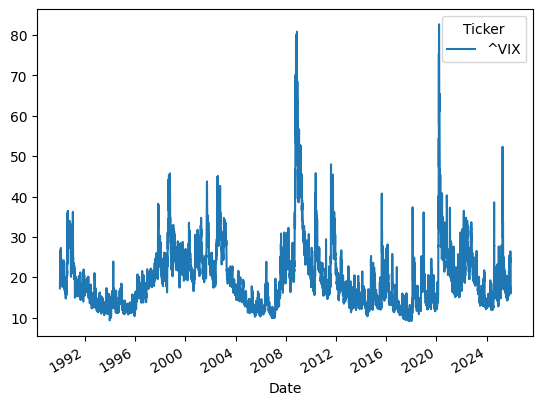

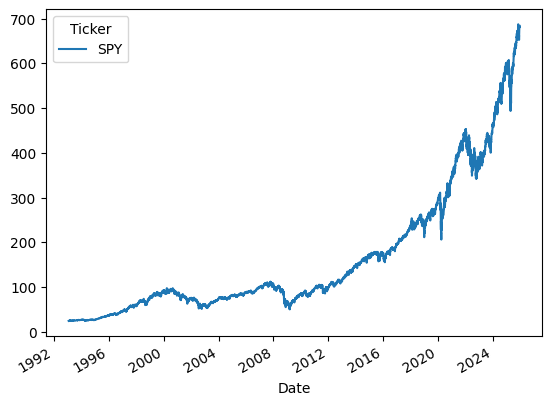

In [27]:
vix_data['Close'].plot()
spy_data['Close'].plot()